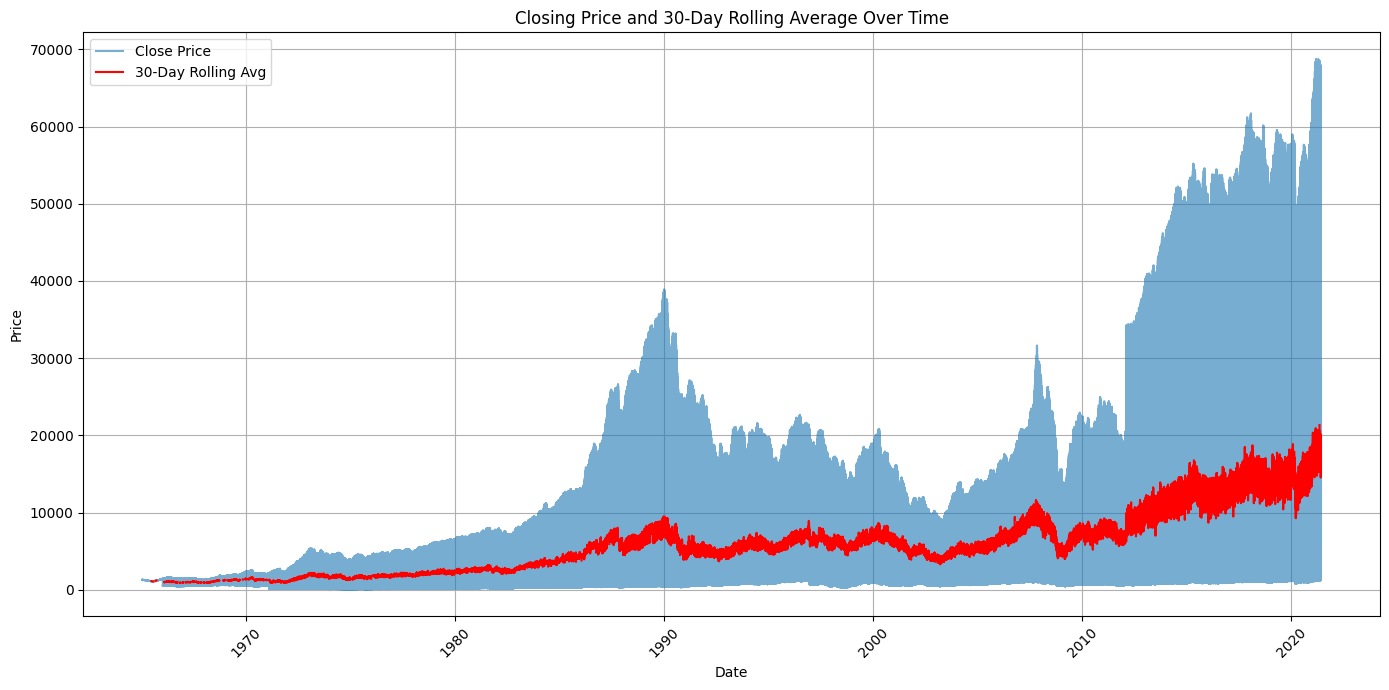


Rolling statistics analysis complete.

First 5 rows with Percentage Change:
        Date       Close  Close_Pct_Change
0 1965-12-31  528.690002               NaN
1 1966-01-03  527.210022         -0.002799
2 1966-01-04  527.840027          0.001195
3 1966-01-05  531.119995          0.006214
4 1966-01-06  532.070007          0.001789


<ipython-input-21-2953791085>:35: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Close_Pct_Change'] = df['Close'].pct_change()


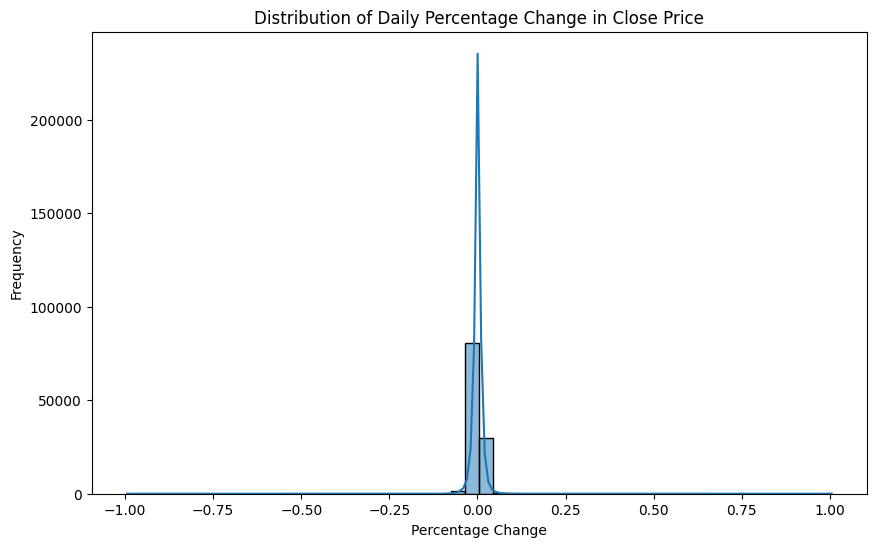


Percentage change analysis complete.

Value counts for 'Index' column:
Index
N225         14500
NYA          13948
IXIC         12690
GSPTSE       10776
HSI           8750
GDAXI         8606
SSMI          7830
KS11          6181
TWII          6010
000001.SS     5963
399001.SZ     5928
N100          5507
NSEI          3381
J203.JO       2387
Name: count, dtype: int64

Normalized value counts for 'Index' column:
Index
N225         0.128938
NYA          0.124030
IXIC         0.112843
GSPTSE       0.095823
HSI          0.077808
GDAXI        0.076527
SSMI         0.069627
KS11         0.054963
TWII         0.053443
000001.SS    0.053025
399001.SZ    0.052713
N100         0.048970
NSEI         0.030065
J203.JO      0.021226
Name: proportion, dtype: float64

Value count analysis complete.

Pivot Table: Average Close Price by Year and Index:
Index    000001.SS     399001.SZ         GDAXI        GSPTSE           HSI  \
Year                                                                       

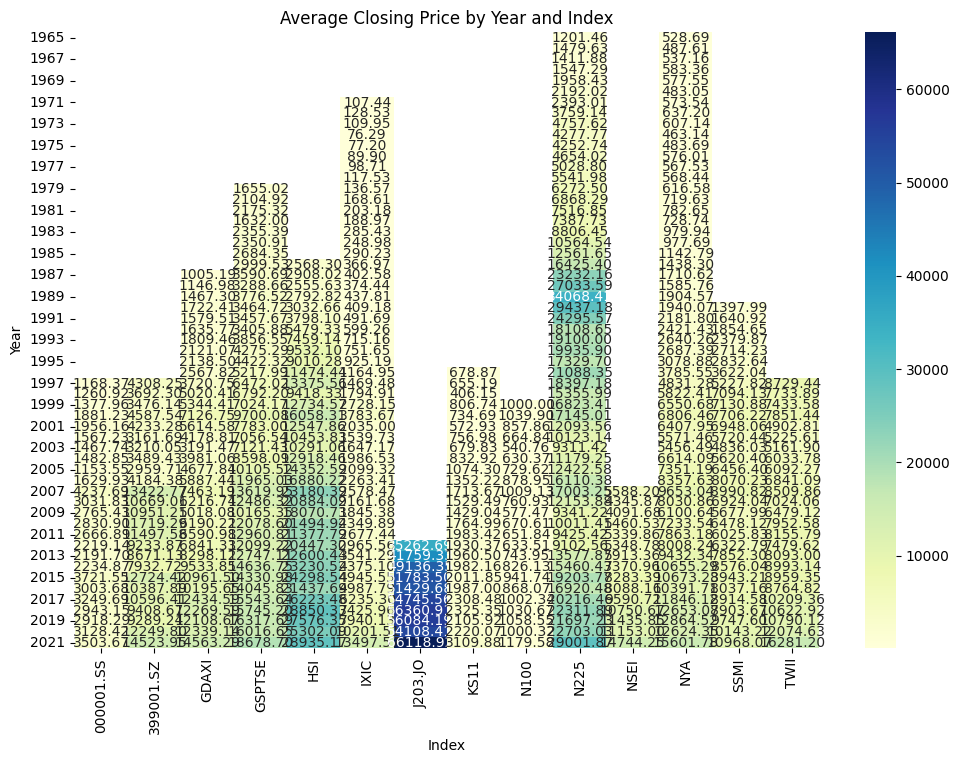


Pivot table analysis complete.

First 5 rows of data from 2020:
      Index       Date         Open         High          Low        Close  \
13593   NYA 2020-01-02  13913.03027  14003.38965  13913.03027  14002.49023   
13594   NYA 2020-01-03  13877.48047  13950.74023  13870.74023  13917.04981   
13595   NYA 2020-01-06  13856.71973  13943.29981  13852.73047  13941.79981   
13596   NYA 2020-01-07  13911.19043  13923.50977  13880.53027  13898.45020   
13597   NYA 2020-01-08  13897.00977  13986.69043  13896.58984  13934.44043   

         Adj Close        Volume  Close_Pct_Change  Year  
13593  14002.49023  3.458250e+09          0.006430  2020  
13594  13917.04981  3.461290e+09         -0.006102  2020  
13595  13941.79981  3.674070e+09          0.001778  2020  
13596  13898.45020  3.420380e+09         -0.003109  2020  
13597  13934.44043  3.720890e+09          0.002590  2020  

First 5 rows of '^GSPC' data from 2020:
Empty DataFrame
Columns: [Index, Date, Open, High, Low, Close, Adj Clos

In [21]:
# prompt: Data Exploration Operations

import pandas as pd
import matplotlib.pyplot as plt

if 'Date' in df.columns:
  # Ensure 'Date' is datetime and sort
  df['Date'] = pd.to_datetime(df['Date'])
  df_time = df.sort_values(by='Date')

  # Calculate rolling average
  window_size = 30
  df_time['Close_Rolling_Avg'] = df_time['Close'].rolling(window=window_size).mean()

  # Plot the original close price and the rolling average
  plt.figure(figsize=(14, 7))
  plt.plot(df_time['Date'], df_time['Close'], label='Close Price', alpha=0.6)
  plt.plot(df_time['Date'], df_time['Close_Rolling_Avg'], label=f'{window_size}-Day Rolling Avg', color='red')
  plt.title(f'Closing Price and {window_size}-Day Rolling Average Over Time')
  plt.xlabel('Date')
  plt.ylabel('Price')
  plt.legend()
  plt.grid(True)
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

else:
  print("\n'Date' column not found. Cannot calculate and plot rolling statistics.")

print("\nRolling statistics analysis complete.")

# Example: Calculating percentage change
# Calculate the daily percentage change in 'Close' price
df['Close_Pct_Change'] = df['Close'].pct_change()

print("\nFirst 5 rows with Percentage Change:")
print(df[['Date', 'Close', 'Close_Pct_Change']].head())

# Optional: Plot the distribution of percentage change
plt.figure(figsize=(10, 6))
sns.histplot(df['Close_Pct_Change'].dropna(), bins=50, kde=True) # Drop NaN from the first row
plt.title('Distribution of Daily Percentage Change in Close Price')
plt.xlabel('Percentage Change')
plt.ylabel('Frequency')
plt.show()

print("\nPercentage change analysis complete.")

# Example: Value counts for categorical data
# Let's check the distribution of values in the 'Index' column again
if 'Index' in df.columns:
  print("\nValue counts for 'Index' column:")
  print(df['Index'].value_counts())
  print("\nNormalized value counts for 'Index' column:")
  print(df['Index'].value_counts(normalize=True))
else:
  print("\n'Index' column not found for value count analysis.")

print("\nValue count analysis complete.")

# Example: Creating a pivot table
# Let's create a pivot table showing the average 'Close' price for each 'Index' per year
# This requires the 'Date' column and 'Index' column
if 'Date' in df.columns and 'Index' in df.columns:
  df['Year'] = df['Date'].dt.year
  pivot_table_avg_close = pd.pivot_table(df, values='Close', index='Year', columns='Index', aggfunc='mean')

  print("\nPivot Table: Average Close Price by Year and Index:")
  print(pivot_table_avg_close)

  # Optional: Plot the pivot table as a heatmap
  plt.figure(figsize=(12, 8))
  sns.heatmap(pivot_table_avg_close, annot=True, fmt=".2f", cmap="YlGnBu")
  plt.title('Average Closing Price by Year and Index')
  plt.xlabel('Index')
  plt.ylabel('Year')
  plt.show()

else:
  print("\n'Date' or 'Index' column not found. Cannot create pivot table.")

print("\nPivot table analysis complete.")

# Example: Filtering data
# Filter for data from a specific year, e.g., 2020
if 'Date' in df.columns:
  df_2020 = df[df['Date'].dt.year == 2020]
  print("\nFirst 5 rows of data from 2020:")
  print(df_2020.head())

  # Filter for a specific index and year, e.g., '^GSPC' in 2020
  if 'Index' in df.columns:
    df_gspc_2020 = df[(df['Date'].dt.year == 2020) & (df['Index'] == '^GSPC')]
    print("\nFirst 5 rows of '^GSPC' data from 2020:")
    print(df_gspc_2020.head())
  else:
    print("\n'Index' column not found. Cannot filter by index and year.")

else:
  print("\n'Date' column not found. Cannot filter by year.")

print("\nFiltering examples complete.")
